In [2]:
pwd

'/gpfs/exfel/u/usr/SCS/202201/p002884/Software/zoey/EuXFEL/notebooks'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import dask
import dask.array as da
import xarray as xr
from extra_data import open_run

from itertools import combinations
from dask.distributed import Client, progress, performance_report
from dask_jobqueue import SLURMCluster

import pandas as pd
from tqdm.notebook import tqdm
import matplotlib as mpl
plt.style.use('../misc/zoey_style.mplstyle')

from os.path import basename, exists

from glob import glob
from pathlib import Path
from lmfit import Model, Parameters
from scipy.special import gamma, factorial, loggamma
import re

import sys
import matplotlib.patheffects as pe
from lmfit import Model, Parameters
import scipy.special as sp
from matplotlib.colors import LogNorm

from importlib import reload
from skimage.measure import regionprops
import h5py
from skimage.filters import sobel

mpl.rcParams['figure.figsize'] = (10,10)

# metadata

In [4]:
current = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
dark_runNB = [69,  72,  72,  75,  75,  78,  78,  81,  81]
runNB =      [70,  71,  73,  74,  76,  77,  79,  80,  82]
modules = [15, 0, 8, 7]
proposalNB = 2884

run_index = 0

field = current[run_index]
run = runNB[run_index]
dark_run = dark_runNB[run_index]
module = modules[1]
group = 0

# photon maps saved in scratch/LS/Reduced_Data/reduced_3-17-23/

In [9]:
imgs_photon = np.load(f'/gpfs/exfel/u/scratch/SCS/202201/p002884/LS/Reduced_Data/reduced_3-17-23/r{run}m{module}_{group}_photon.npy', 'r')
imgs_photon.shape

(300, 200, 128, 512)

In [14]:
imgs_photon.min(), imgs_photon.max(), imgs_photon.dtype

(-16.0, 90.0, dtype('float64'))

In [190]:
imgs_photon[1,0,:10,:10]

memmap([[ 1.,  0., -0.,  0., -1., -0.,  0.,  0., -0.,  0.],
        [ 0., -0.,  0., -0.,  0., -0.,  1.,  1.,  0.,  0.],
        [-0.,  0.,  0., -0., -0., -0.,  1., -0.,  1.,  0.],
        [ 0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0., -0.],
        [-0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [-0.,  0., -0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.],
        [-0., -0., -0.,  0.,  1.,  0., -0., -0., -0.,  0.],
        [ 1.,  0.,  1., -0.,  0.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -0.],
        [ 0., -0., -0.,  0., -0., -0., -0.,  1., -0.,  0.]])

## single image

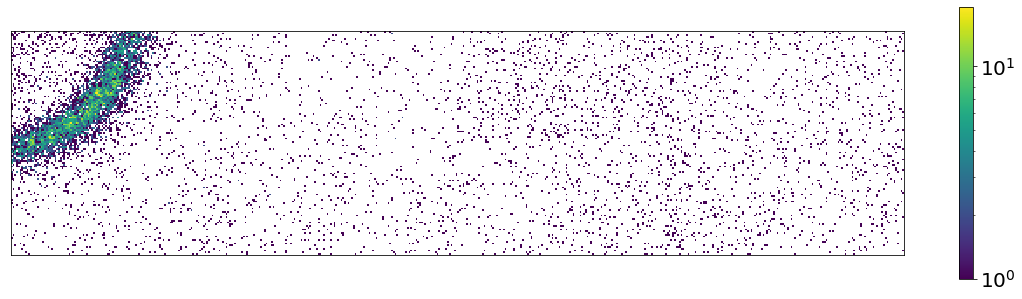

In [29]:
img = imgs_photon[0,0]

plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

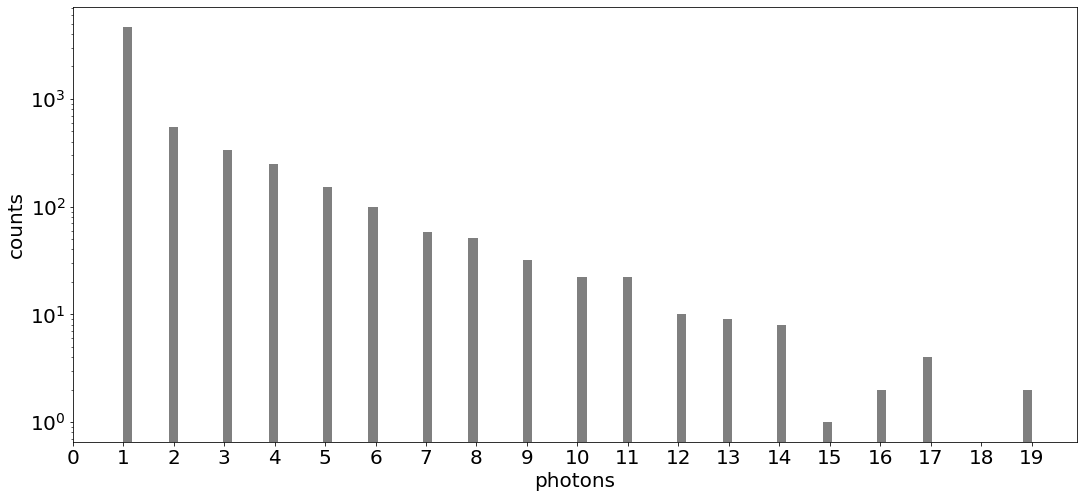

In [30]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img[np.logical_and(img>0, img<20)].ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('photons')
plt.ylabel(f'counts')
plt.xticks(np.arange(20))
plt.show()

In [170]:
photon_sum.shape

(200, 128, 512)

## integrated image

In [171]:
time_avg_photon_sum = photon_sum / 300

In [173]:
time_avg_photon_sum.min(), time_avg_photon_sum.max()

(-2.0, 17.44)

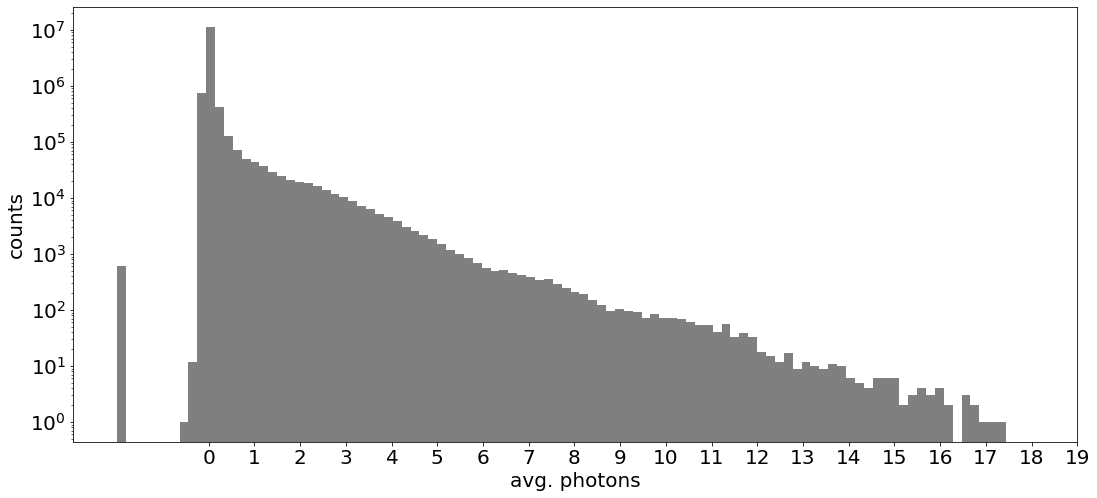

In [172]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(time_avg_photon_sum.ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('avg. photons')
plt.ylabel(f'counts')
plt.xticks(np.arange(20))
plt.show()

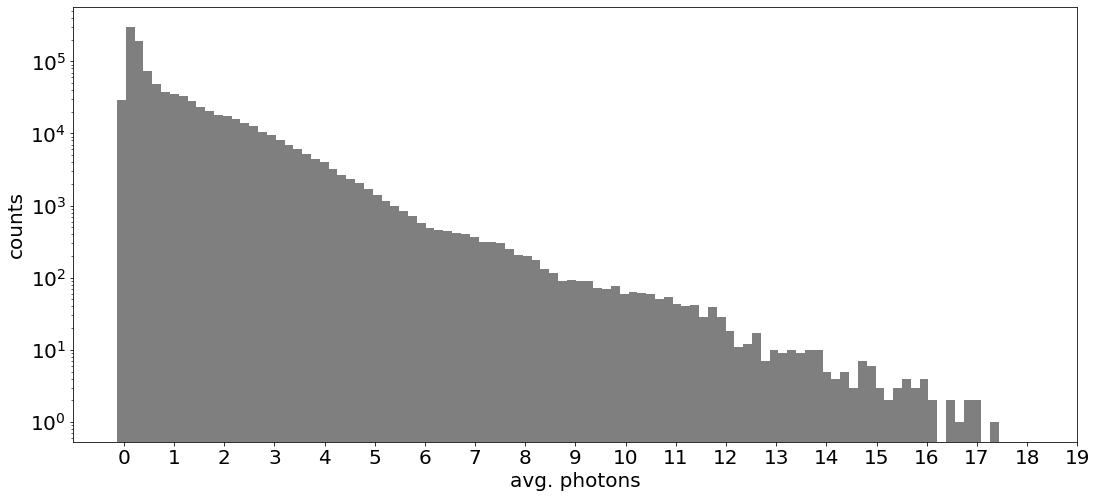

In [174]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(time_avg_photon_sum[:,:70,:70].ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('avg. photons')
plt.ylabel(f'counts')
plt.xticks(np.arange(20))
plt.show()

In [175]:
photon_sum.shape

(200, 128, 512)

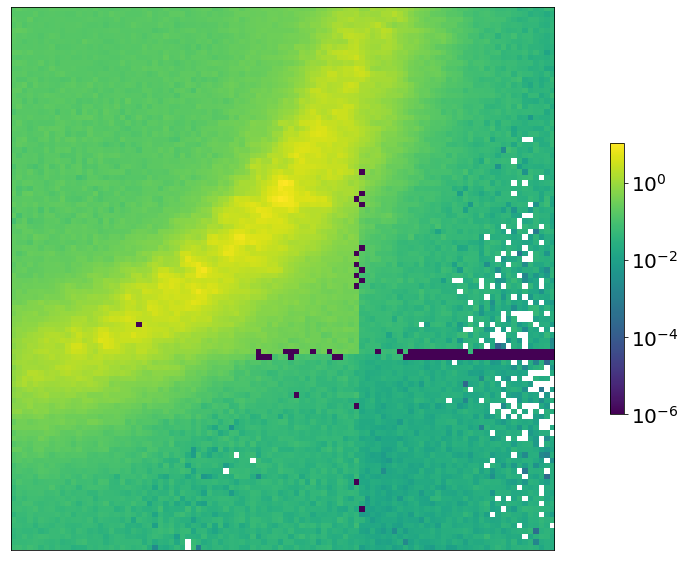

In [183]:
img = photon_sum.mean(axis=0)/300

plt.figure(figsize=(20,10))
plt.imshow(img[:100,:100], norm=LogNorm(vmin=1e-6), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

In [184]:
photon_sum[0,:50,:50]/300

array([[ 0.18      ,  0.04333333,  0.13666667, ...,  0.09      ,
         0.07      ,  0.11666667],
       [ 0.12666667,  0.02      ,  0.10666667, ...,  0.14333333,
         0.09666667,  0.06      ],
       [ 0.12333333,  0.16      ,  0.09666667, ...,  0.11333333,
         0.12      ,  0.11      ],
       ...,
       [ 0.15666667,  0.14666667,  0.03333333, ...,  2.07333333,
         2.02666667,  1.38666667],
       [ 0.15666667,  0.05333333,  0.03      , ...,  2.00666667,
         2.17      ,  1.98      ],
       [-0.00666667,  0.16666667,  0.14      , ...,  0.88666667,
         1.17666667,  1.15333333]])

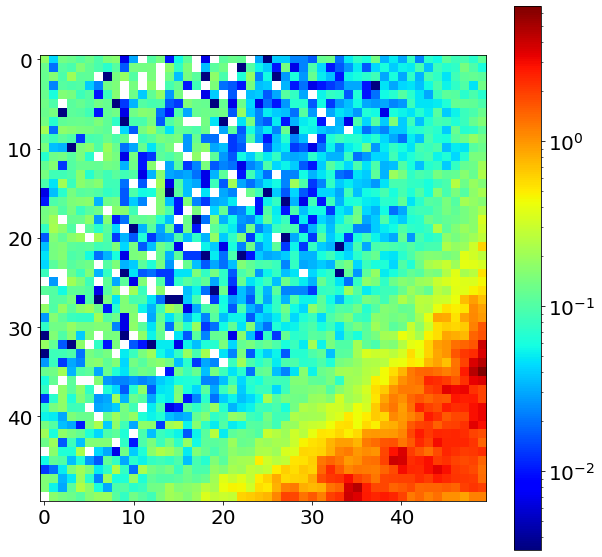

In [185]:
plt.imshow(photon_sum[0,:50,:50]/300,norm=LogNorm(),cmap='jet')
plt.colorbar()

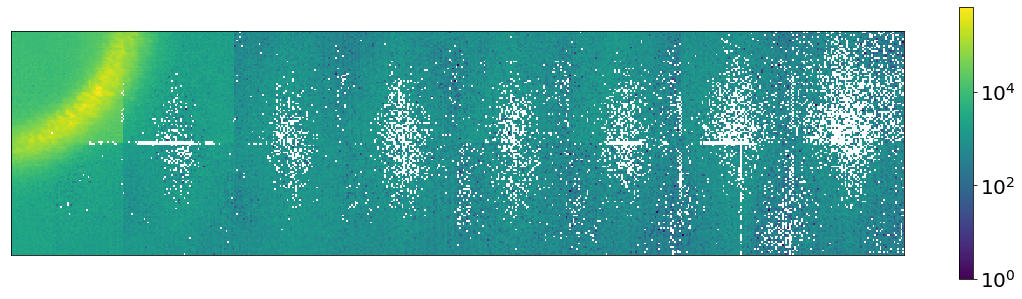

In [73]:
img = photon_sum.sum(axis=0)

plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

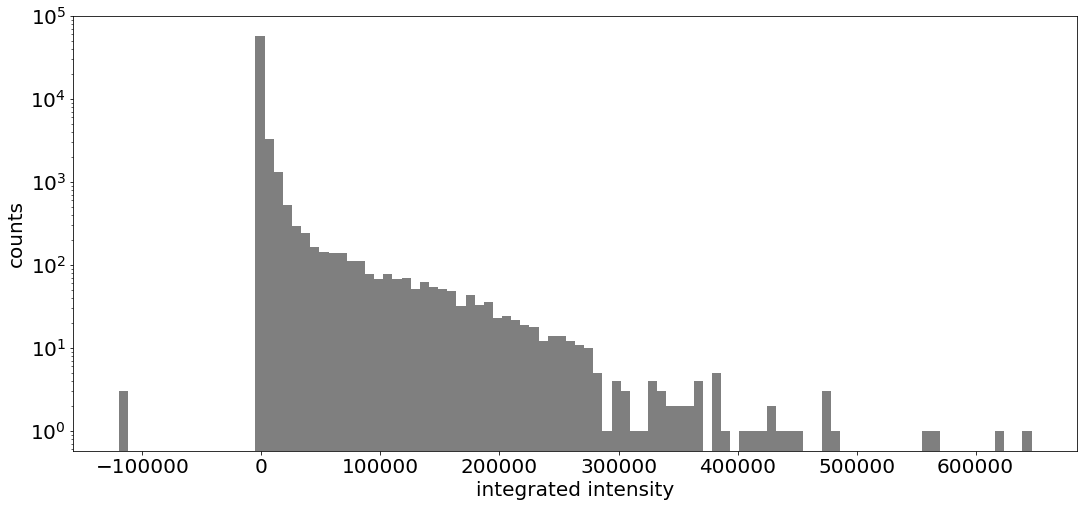

In [27]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img.ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('integrated intensity')
plt.ylabel(f'counts')
plt.show()

## statistics

In [39]:
def neg_binom(k_bar, k, M):
    from scipy import special as sp
    """
    Calculate the negative binomial distribution for photon-arrival events. Details can
    be found in Speckle Phenomena in Optics: Theory and Applications by Goodman. See section
    on speckle at low light levels.

    Parameters:
    k_bar (float): The average number of photons.
    k (int): The number of photons.
    M (int): The number of modes influencing the measurement.

    Returns:
    float: The probability of k photons arriving given an average incident intensity
    (k_bar) and number of modes (M) .
    """
    # Calculate the prefactor using the log-gamma function for numerical stability
    prefactor = np.exp(sp.loggamma(k + M) - sp.loggamma(M) - sp.loggamma(k+1))
    postfactor = ((k_bar/(k_bar+M))**k)*((M/(k_bar+M))**M) # no this is not a factor....

    return prefactor * postfactor

In [82]:
stats_photon = np.zeros((len(imgs_photon), 100))

for i, train in tqdm(enumerate(imgs_photon), total=len(imgs_photon)):
    stats_iter = np.bincount(np.maximum(0, train[:,:70,:70].ravel()).astype(int))
    stats_photon[i, :len(stats_iter)] = stats_iter / (200*70*70)

  0%|          | 0/300 [00:00<?, ?it/s]

In [79]:
stats_photon.shape

(300, 100)

In [80]:
kbar_photon = np.mean(np.maximum(0, imgs_photon[:,:70,:70]), axis=(1,2,3))

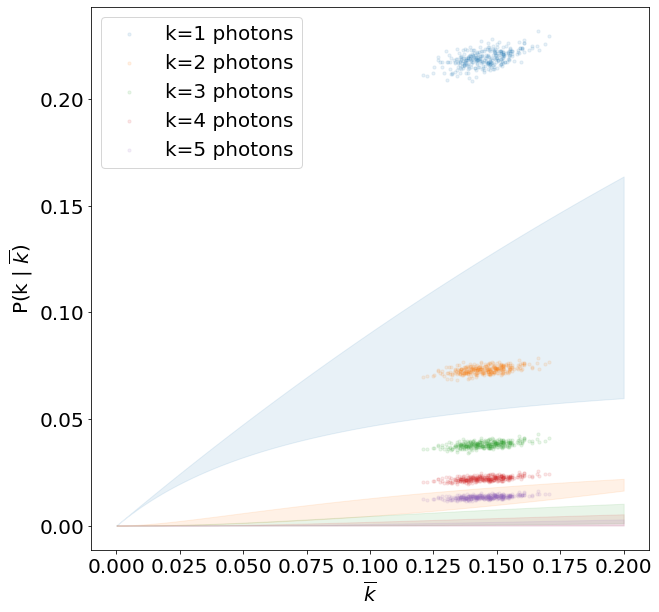

In [88]:
k_min, k_max = 1, 5
M_min, M_max = 0.1, 1000
k_bar = np.linspace(0, 0.2, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(kbar_photon, stats_photon[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

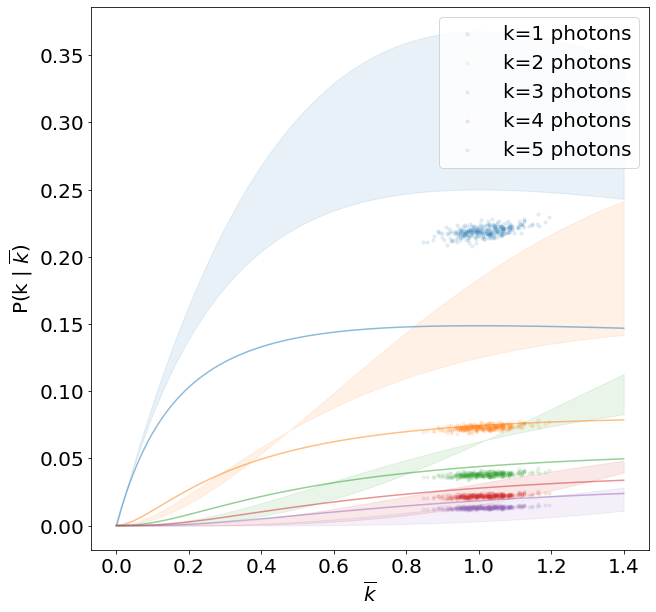

In [164]:
scaler = 7
k_min, k_max = 1, 5
M_min, M_max = 1, 1000
k_bar = np.linspace(0, 0.2*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_photon, stats_photon[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=0.3), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

In [38]:
def neg_binom_scaled(k_bar, k, M, kbar_scaler):
    return(neg_binom(k_bar*kbar_scaler, k, M))
    
    
def fit_contrasts_scaled_kbar(data, k_bar):
    mask = data > 0 # remove P=0 (no photon) events
    
    k_fit = np.broadcast_to(np.arange(data.shape[-1]), data.shape)
    mask[k_fit<1] = False
    mask[k_fit>5] = False
    mask = np.ravel(mask)
    
    Y = np.ravel(data)[mask]
    X = np.ravel(k_bar)[mask]
    k = np.ravel(k_fit)[mask]
    
    
    model = Model(neg_binom_scaled, independent_vars=['k_bar', 'k'])
    params = Parameters()
    params.add('M', value=4, min=0.001, max=10000)    
    params.add('kbar_scaler', value=4, min=0.1, max=10)   
    result = model.fit(data=Y, k_bar=X, k=k, **params, nan_policy='omit')
    
    return result

In [167]:
res_photon = fit_contrasts_scaled_kbar(stats_photon, np.broadcast_to(np.expand_dims(kbar_photon, axis=1), stats_photon.shape))
res_photon

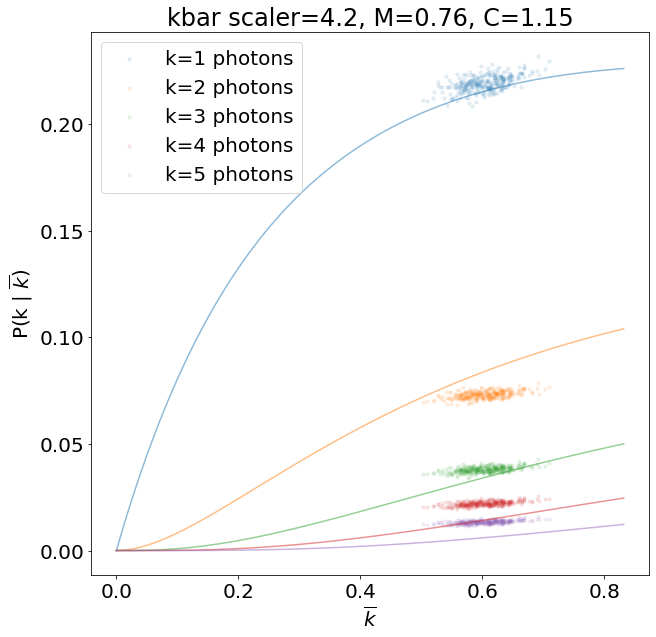

In [168]:
scaler = res_photon.best_values['kbar_scaler']
M = res_photon.best_values['M']

k_min, k_max = 1, 5
M_min, M_max = 1, 1000
k_bar = np.linspace(0, 0.2*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_photon, stats_photon[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=M), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.title(f'kbar scaler={scaler:.1f}, M={M:.2f}, C={1/np.sqrt(M):.2f}')
plt.legend()
plt.show()

In [157]:
stats_photon.shape

(300, 100)

In [158]:
stats_photon_first_pulse = np.zeros((len(imgs_photon), 100))

for i, train in tqdm(enumerate(imgs_photon), total=len(imgs_photon)):
    stats_iter = np.bincount(np.maximum(0, train[0,:70,:70].ravel()).astype(int))
    stats_photon_first_pulse[i, :len(stats_iter)] = stats_iter / (70*70)

  0%|          | 0/300 [00:00<?, ?it/s]

In [159]:
stats_photon_first_pulse.shape

(300, 100)

In [ ]:
np.mean(stats_photon_first_pulse)

# gain modified (save_real_photon_maps output)
this is basically just multiplying by 0.2 and rounding to an integer between 0 and 255

In [160]:
18089*200

3617800

In [33]:
file = f'../data/photon_maps/run{run:03d}_module{module:02d}.h5'

with h5py.File(file, 'r') as f:
    print(f.keys())
    imgs_gain = f['photon_maps'][:10,:]
    imgs_gain_sum = f['integrated_photon_maps'][:]
    print(f['photon_maps'].shape)

<KeysViewHDF5 ['integrated_photon_maps', 'photon_maps']>
(18089, 200, 128, 512)


In [40]:
imgs_gain.min(), imgs_gain.max(), imgs_gain.dtype

(0, 18, dtype('uint8'))

## single image

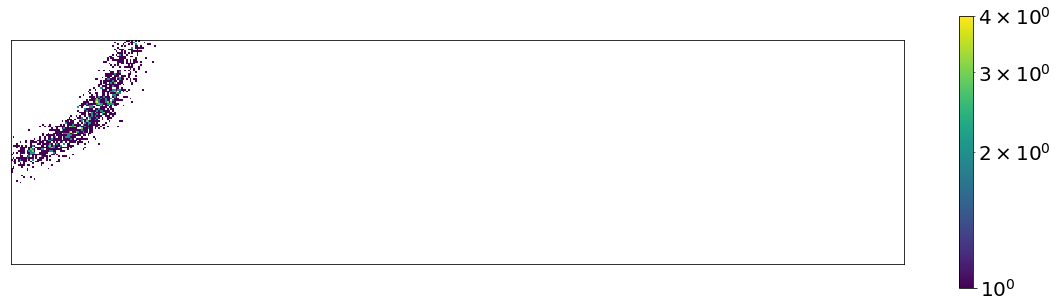

In [37]:
img = imgs_gain[0,0]

plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

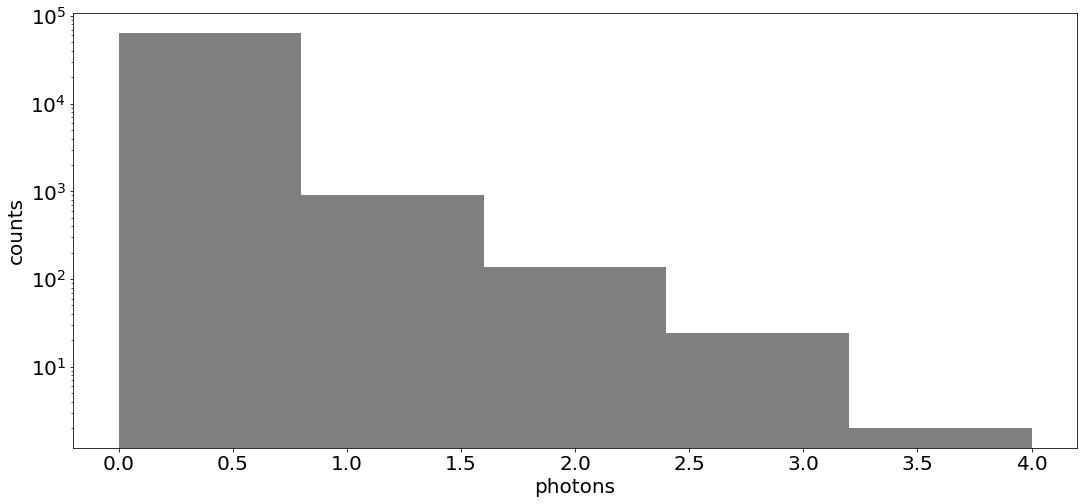

In [42]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img.ravel(), color='k', linewidth=1, bins=len(np.unique(img)), alpha=0.5)
plt.semilogy()
plt.xlabel('photons')
plt.ylabel(f'counts')
plt.show()

## integrated image

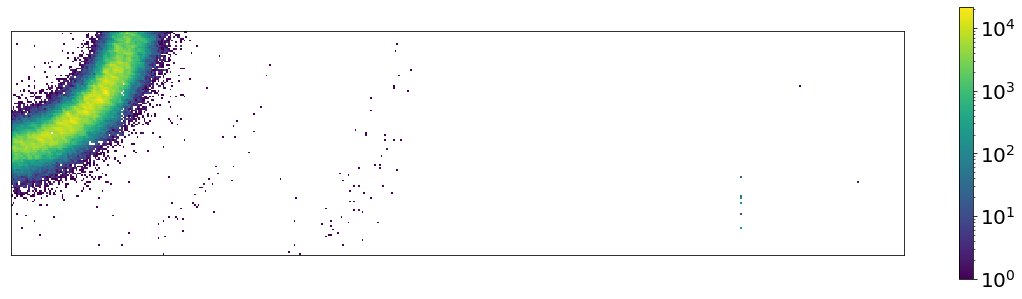

In [43]:
img = imgs_gain_sum[0]

plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

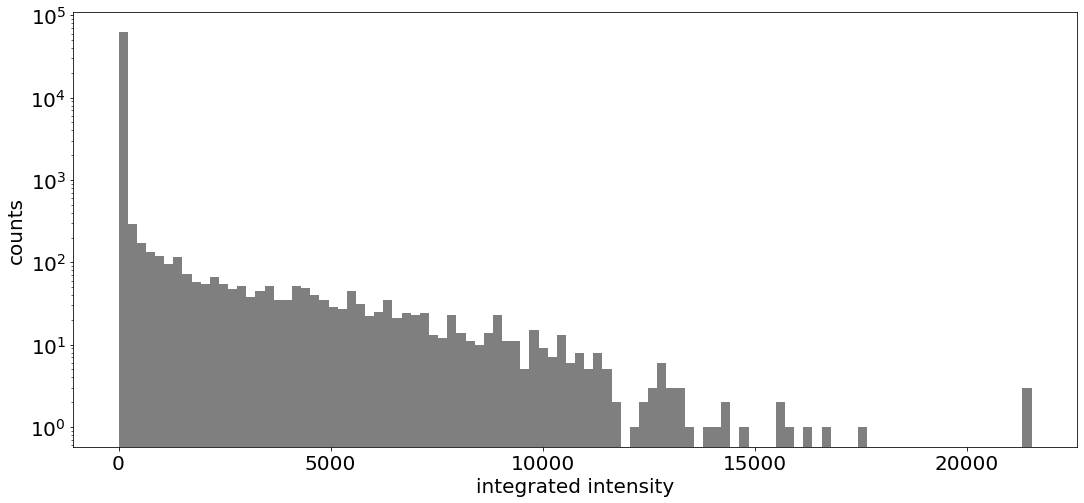

In [44]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img.ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('integrated intensity')
plt.ylabel(f'counts')
plt.show()

## statistics

In [89]:
file = f'../data/photon_maps/run{run:03d}_module{module:02d}.h5'
with h5py.File(file, 'r') as f:
    imgs_gain = f['photon_maps'][:300]

In [90]:
imgs_gain.shape

(300, 200, 128, 512)

In [91]:
stats_gain = np.zeros((len(imgs_gain), 100))

for i, train in tqdm(enumerate(imgs_gain), total=len(imgs_gain)):
    stats_iter = np.bincount(np.maximum(0, train[:,:70,:70].ravel()).astype(int))
    stats_gain[i, :len(stats_iter)] = stats_iter / (200*70*70)

  0%|          | 0/300 [00:00<?, ?it/s]

In [92]:
stats_gain.shape

(300, 100)

In [93]:
kbar_gain = np.mean(np.maximum(0, imgs_gain[:,:70,:70]), axis=(1,2,3))

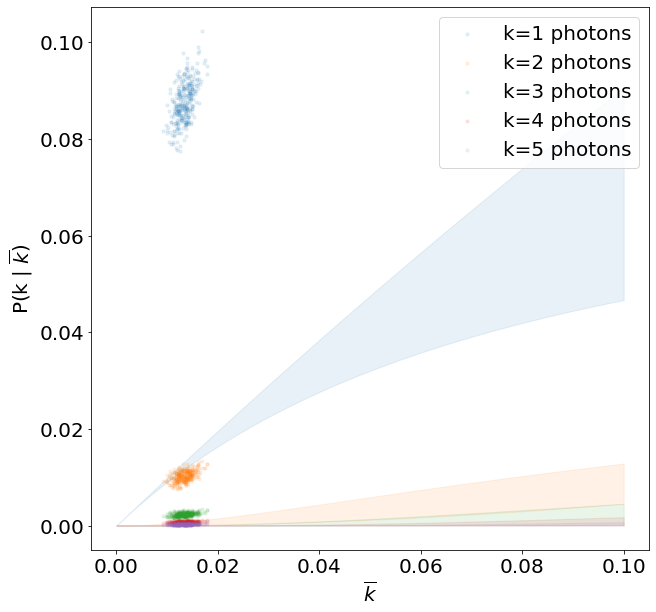

In [95]:
k_min, k_max = 1, 5
M_min, M_max = 0.1, 1000
k_bar = np.linspace(0, 0.1, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(kbar_gain, stats_gain[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

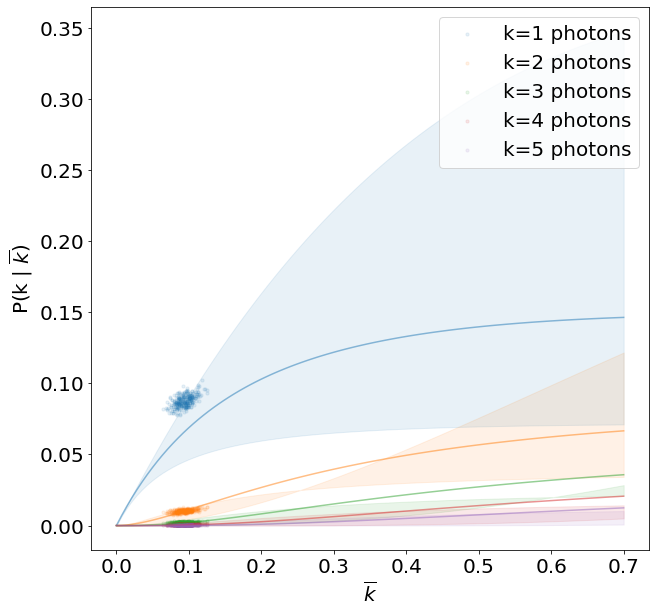

In [143]:
scaler = 7
k_min, k_max = 1, 5
M_min, M_max = 0.1, 1000
k_bar = np.linspace(0, 0.1*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_gain, stats_gain[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=0.3), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

In [144]:
res_gain = fit_contrasts_scaled_kbar(stats_gain, np.broadcast_to(np.expand_dims(kbar_gain, axis=1), stats_gain.shape))
res_gain

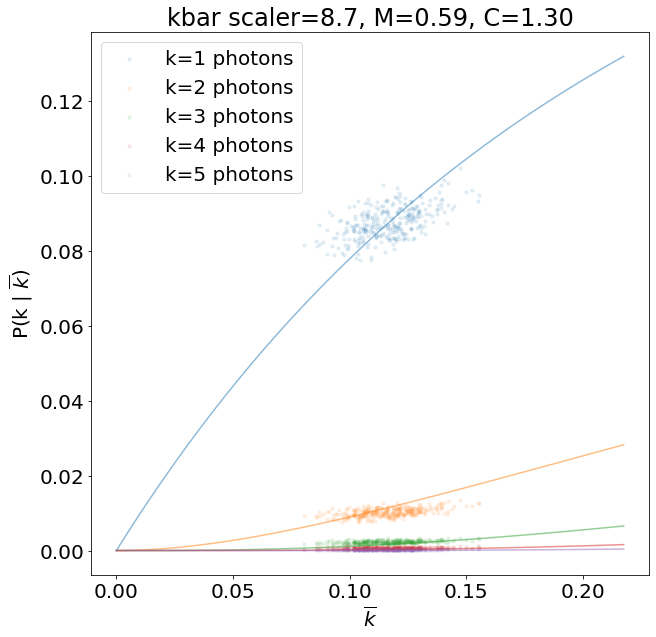

In [169]:
scaler = res_gain.best_values['kbar_scaler']
M = res_gain.best_values['M']

k_min, k_max = 1, 5
M_min, M_max = 1, 1000
k_bar = np.linspace(0, 0.025*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_gain, stats_gain[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=M), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.title(f'kbar scaler={scaler:.1f}, M={M:.2f}, C={1/np.sqrt(M):.2f}')
plt.legend()
plt.show()

# load in aimgs

In [49]:
aimg = np.load(f'/gpfs/exfel/u/scratch/SCS/202201/p002884/LS/aimgs_r{run}.npy', 'r')
aimg.shape

(4, 128, 512)

In [50]:
modules

[15, 0, 8, 7]

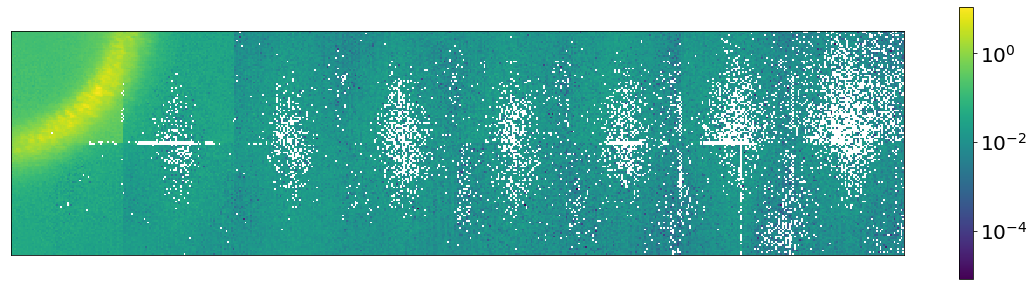

In [51]:
img = aimg[1]
plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

# gain modified (save_real_photon_maps output from raw data)
this is basically just multiplying by 0.2 and rounding to an integer between 0 and 255

In [18]:
file = f'../data/photon_maps/run{run:03d}_module{module:02d}_from_raw_data.h5'

with h5py.File(file, 'r') as f:
    print(f.keys())
    imgs_gain_raw = f['photon_maps'][:10,:]
    imgs_gain_sum_raw = f['integrated_photon_maps'][:]
    print(f['photon_maps'].shape)

<KeysViewHDF5 ['integrated_photon_maps', 'photon_maps']>
(18550, 200, 128, 512)


In [8]:
imgs_gain_raw.min(), imgs_gain_raw.max(), imgs_gain_raw.dtype

(0, 51, dtype('uint8'))

## single image

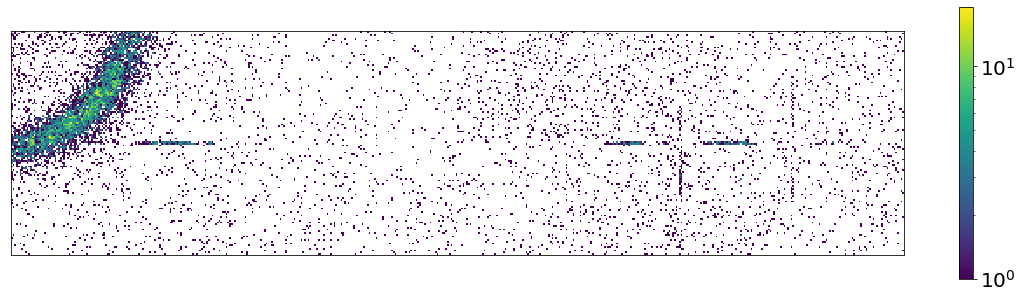

In [10]:
img = imgs_gain_raw[0,0]

plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

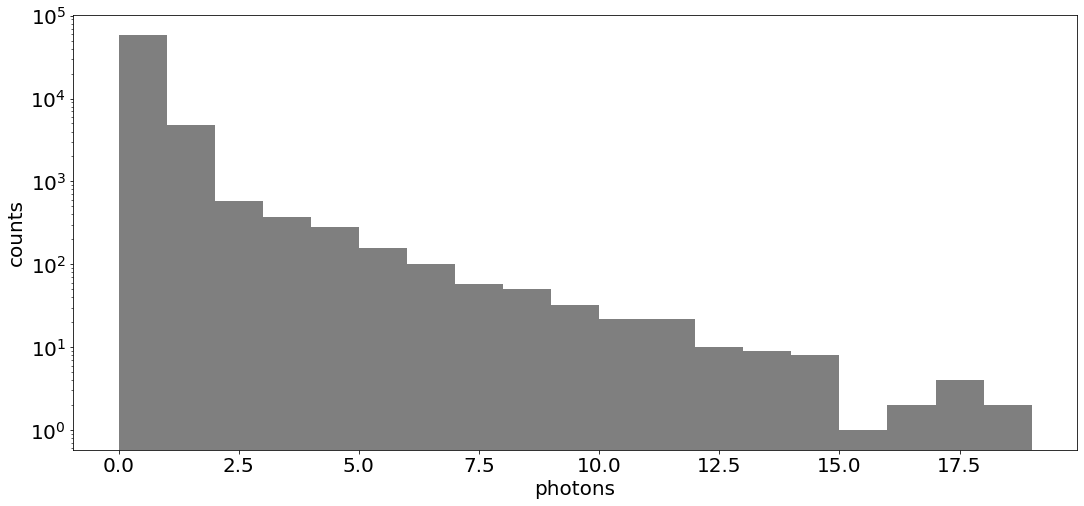

In [11]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img.ravel(), color='k', linewidth=1, bins=len(np.unique(img)), alpha=0.5)
plt.semilogy()
plt.xlabel('photons')
plt.ylabel(f'counts')
plt.show()

## integrated image

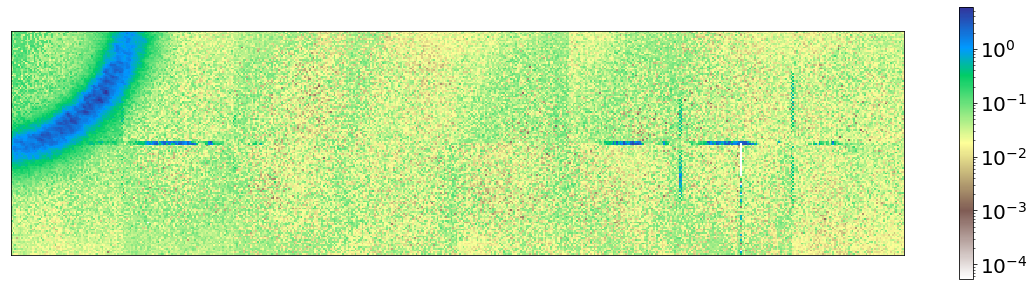

In [27]:
img = imgs_gain_sum_raw[0]

plt.figure(figsize=(20,10))
plt.imshow(img/18550, norm=LogNorm(), interpolation='none', cmap='terrain_r')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

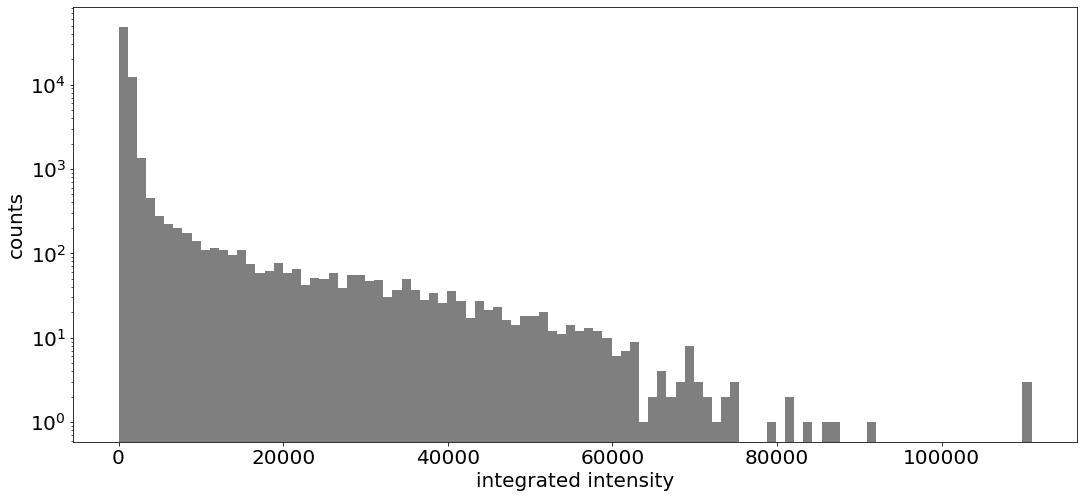

In [28]:
plt.figure(figsize=(18,8))
ax = plt.gca()

N, bins, patches = ax.hist(img.ravel(), color='k', linewidth=1, bins=100, alpha=0.5)
plt.semilogy()
plt.xlabel('integrated intensity')
plt.ylabel(f'counts')
plt.show()

## statistics

In [30]:
with h5py.File(file, 'r') as f:
    imgs_gain_raw = f['photon_maps'][:300]

In [31]:
imgs_gain_raw.shape

(300, 200, 128, 512)

In [33]:
train.shape

(100,)

In [34]:
stats_gain_raw = np.zeros((len(imgs_gain_raw), 100))

for i, train in tqdm(enumerate(imgs_gain_raw), total=len(stats_gain_raw)):
    stats_iter = np.bincount(np.maximum(0, train[:,:70,:70].ravel()).astype(int))
    stats_gain_raw[i, :len(stats_iter)] = stats_iter / (200*70*70)

  0%|          | 0/300 [00:00<?, ?it/s]

In [35]:
stats_gain_raw.shape

(300, 100)

In [36]:
kbar_gain_raw = np.mean(np.maximum(0, imgs_gain_raw[:,:70,:70]), axis=(1,2,3))

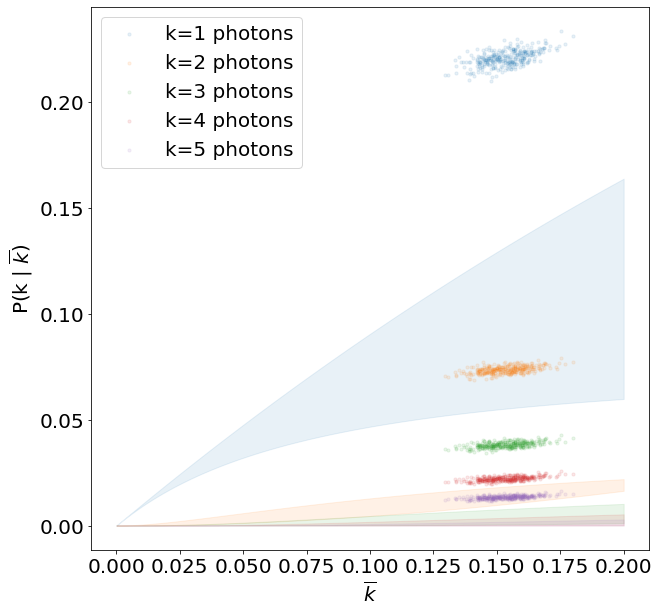

In [41]:
k_min, k_max = 1, 5
M_min, M_max = 0.1, 1000
k_bar = np.linspace(0, 0.2, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(kbar_gain_raw, stats_gain_raw[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

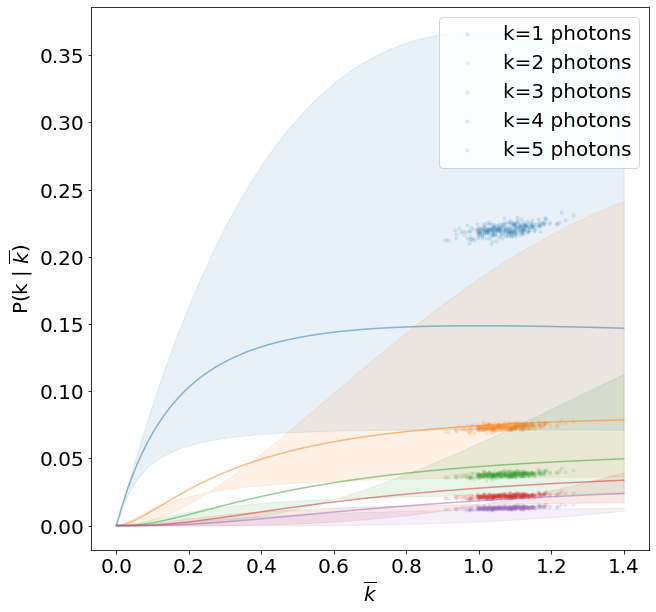

In [43]:
scaler = 7
k_min, k_max = 1, 5
M_min, M_max = 0.1, 1000
k_bar = np.linspace(0, 0.2*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_gain_raw, stats_gain_raw[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.fill_between(k_bar, neg_binom(k_bar, k_iter, M=M_max), neg_binom(k_bar, k_iter, M=M_min),
                    alpha=0.1, color=f'C{i}')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=0.3), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.legend()
plt.show()

In [44]:
res_gain_raw = fit_contrasts_scaled_kbar(stats_gain_raw, np.broadcast_to(np.expand_dims(kbar_gain_raw, axis=1), stats_gain_raw.shape))
res_gain_raw

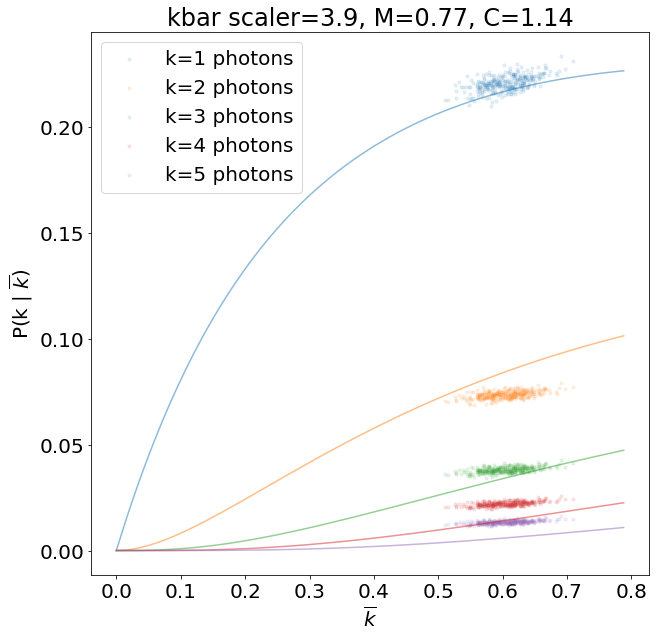

In [46]:
scaler = res_gain_raw.best_values['kbar_scaler']
M = res_gain_raw.best_values['M']

k_min, k_max = 1, 5
M_min, M_max = 1, 1000
k_bar = np.linspace(0, 0.2*scaler, 100)

plt.figure()
for i, k_iter in enumerate(range(k_min, k_max+1)):
    plt.scatter(scaler*kbar_gain_raw, stats_gain_raw[:,k_iter], color=f'C{i}', alpha=0.1, s=10, label=f'k={k_iter:0d} photons')
    plt.plot(k_bar, neg_binom(k_bar, k_iter, M=M), alpha=0.5, color=f'C{i}')
plt.ylabel(r'P(k | $\overline{k}$)')
plt.xlabel(r'$\overline{k}$')
plt.title(f'kbar scaler={scaler:.1f}, M={M:.2f}, C={1/np.sqrt(M):.2f}')
plt.legend()
plt.show()

# load in aimgs

In [49]:
aimg = np.load(f'/gpfs/exfel/u/scratch/SCS/202201/p002884/LS/aimgs_r{run}.npy', 'r')
aimg.shape

(4, 128, 512)

In [50]:
modules

[15, 0, 8, 7]

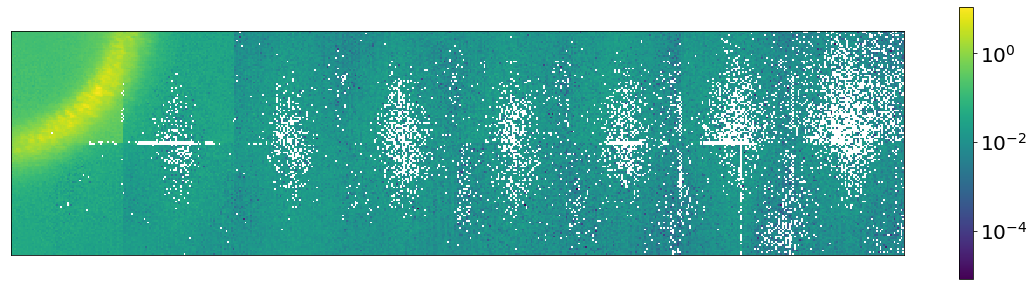

In [51]:
img = aimg[1]
plt.figure(figsize=(20,10))
plt.imshow(img, norm=LogNorm(), interpolation='none')
plt.colorbar(shrink=0.5)
plt.xticks([])
plt.yticks([])
plt.show()

# misc

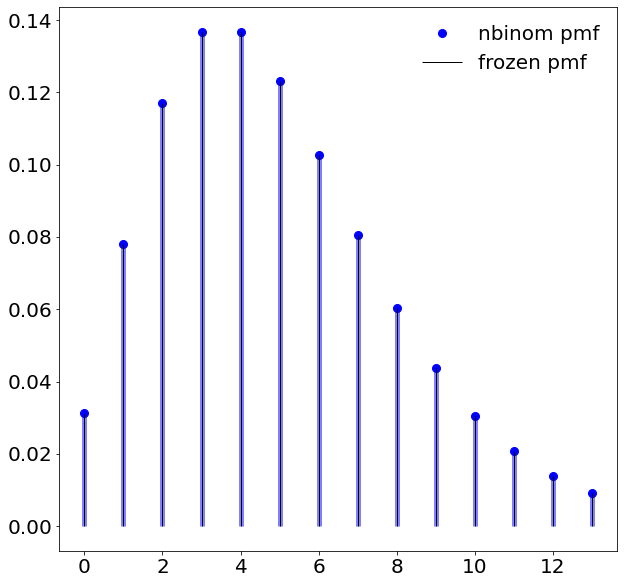

In [155]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.nbinom.html
from scipy.stats import nbinom

n, p = 5, 0.5
mean, var, skew, kurt = nbinom.stats(n, p, moments='mvsk')
x = np.arange(nbinom.ppf(0.01, n, p),
              nbinom.ppf(0.99, n, p))

fig, ax = plt.subplots()
ax.plot(x, nbinom.pmf(x, n, p), 'bo', ms=8, label='nbinom pmf')
ax.vlines(x, 0, nbinom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)

rv = nbinom(n, p)
ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')
ax.legend(loc='best', frameon=False)
plt.show()